# Relevance Classification — Mechanistic Approach

Two parts:
- **Part A** — Rule-based scoring applied to GT (human-annotated) features — ceiling test
- **Part B** — Same rules applied to LLM-extracted features — end-to-end pipeline

In [17]:
import os
os.chdir(r"C:\Users\beav3503\dev\llm_metadata")

import sys
sys.path.insert(0, "src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

## Data Loading & GT Preparation

In [18]:
# Load dev subset manifest and raw xlsx
manifest = pd.read_csv("data/manifests/dev_subset_data_paper.csv")
raw = pd.read_excel("data/dataset_092624.xlsx")

print(f"Dev subset: {len(manifest)} records")
print(f"Raw xlsx: {len(raw)} records")
print(f"Manifest columns: {list(manifest.columns[:6])}")
print(f"Raw columns sample: {list(raw.columns[:10])}")

Dev subset: 30 records
Raw xlsx: 418 records
Manifest columns: ['gt_record_id', 'source', 'title', 'abstract', 'source_doi', 'source_url']
Raw columns sample: ['id', 'url', 'title', 'full_text', 'publication_year', 'source', 'id_query', 'reason_non_valid', 'valid_yn', 'dataset_relevance']


In [19]:
# Join manifest with raw xlsx on id/record_id
df = raw[raw["id"].isin(manifest["gt_record_id"])].copy()
print(f"Matched records: {len(df)}")

# Normalize GT relevance
df["gt_relevance"] = df["dataset_relevance"].replace({"No dataset": "X", " X": "X"}).str.strip()

# Distribution
print("\nGT relevance distribution:")
print(df["gt_relevance"].value_counts())

# Drop cant access
eval_df = df[df["gt_relevance"].isin(["H", "M", "L", "X"])].copy()
print(f"\nEvaluation records (excluding 'cant access'): {len(eval_df)}")
print(eval_df["gt_relevance"].value_counts())

Matched records: 30

GT relevance distribution:
gt_relevance
M    12
L    11
H     6
X     1
Name: count, dtype: int64

Evaluation records (excluding 'cant access'): 30
gt_relevance
M    12
L    11
H     6
X     1
Name: count, dtype: int64


## Part A — Rule-Based Scoring on GT Features

Apply Fuster et al. rules to GT (human-annotated) features to establish a ceiling.

In [20]:
# Inspect relevant GT columns
gt_cols = [
    "id", "data_type", "temp_range_i", "temp_range_f", "spatial_range_km2",
    "multispecies", "threatened_species", "new_species_science", "new_species_region",
    "bias_north_south", "dataset_relevance", "gt_relevance",
    "MC_dataset_type", "MC_spatial_range", "MC_temporal_range",
    "MC_relevance", "MC_relevance_modifiers"
]
available_cols = [c for c in gt_cols if c in eval_df.columns]
print("Available columns:", available_cols)
eval_df[available_cols].head(5)

Available columns: ['id', 'data_type', 'temp_range_i', 'temp_range_f', 'spatial_range_km2', 'multispecies', 'threatened_species', 'new_species_science', 'new_species_region', 'bias_north_south', 'dataset_relevance', 'gt_relevance', 'MC_dataset_type', 'MC_spatial_range', 'MC_temporal_range', 'MC_relevance', 'MC_relevance_modifiers']


,id,data_type,temp_range_i,temp_range_f,spatial_range_km2,multispecies,threatened_species,new_species_science,new_species_region,bias_north_south,dataset_relevance,gt_relevance,MC_dataset_type,MC_spatial_range,MC_temporal_range,MC_relevance,MC_relevance_modifiers
2,5,EBV genetic analysis,2006,2007,not given,False,True,False,False,False,M,M,H,X,L,L,M
4,9,density,2008,2008,not given,False,False,False,False,False,L,L,H,X,L,L,L
6,11,presence only,1999,2011,7250,False,True,False,False,False,M,M,L,M,H,L,M
7,12,other,2004,2011,7250,False,True,False,False,False,M,M,X,M,M,M,H
11,19,"presence only, EBV genetic analysis",2011,2014,2080,False,False,False,False,False,M,M,H,L,M,M,M


## Scoring Functions

Implement the three Main Classifiers and aggregation logic from Fuster et al.

In [21]:
# Score ordering for numeric comparison
SCORE_ORDER = {"H": 3, "M": 2, "L": 1, "X": 0}
SCORE_FROM_INT = {3: "H", 2: "M", 1: "L", 0: "X"}


def score_data_type(data_type) -> str:
    """Score data type classifier (H/M/L/X) per paper Table 2.
    
    H: abundance, density, EBV genetic analysis
    M: distribution, presence-absence, species richness, relative abundance
    L: presence-only, non-EBV genetic analysis
    X: everything else (no species/biodiversity data, "other", unknown)
    """
    if data_type is None or (isinstance(data_type, float) and np.isnan(data_type)):
        return "X"
    
    dt = str(data_type).lower().strip()
    
    # H: abundance, density, EBV genetic analysis
    if any(x in dt for x in ["abundance", "density", "genetic", "ebv"]):
        # But "non-EBV genetic" is L, and "relative abundance" is M
        if "non-ebv" in dt or "non_ebv" in dt:
            return "L"
        if "relative" in dt:
            return "M"
        return "H"
    
    # M: distribution, presence-absence, species richness, relative abundance
    if any(x in dt for x in ["distribution", "presence-absence", "presence_absence",
                               "species_richness", "species richness", "richness", "relative"]):
        return "M"
    
    # L: presence-only, non-EBV genetic analysis
    if "presence" in dt:
        return "L"
    
    # X: everything else ("other", "tracking", "acoustic", "morphological", etc.)
    return "X"


def score_temporal(temp_range_i, temp_range_f) -> str:
    """Score temporal extent classifier (H/M/L/X).
    
    Uses inclusive year counting: 2009-2011 = 3 years (not 2).
    This matches the authors' scoring (verified against MC_temporal_range).
    
    Thresholds (inclusive calendar years):
      H: > 10 years
      M: 3-10 years
      L: < 3 years (1-2 years)
      X: not stated / missing
    """
    try:
        start = float(temp_range_i)
        end = float(temp_range_f)
        if np.isnan(start) or np.isnan(end):
            return "X"
        duration = end - start + 1  # inclusive counting
        if duration > 10:
            return "H"
        elif duration >= 3:
            return "M"
        else:
            return "L"
    except (TypeError, ValueError):
        return "X"


def score_spatial(spatial_range_km2) -> str:
    """Score spatial extent classifier (H/M/L/X)."""
    try:
        km2 = float(spatial_range_km2)
        if np.isnan(km2):
            return "X"
        if km2 > 15000:
            return "H"
        elif km2 >= 5000:
            return "M"
        else:
            return "L"
    except (TypeError, ValueError):
        return "X"


def majority_vote(scores: list[str]) -> str:
    """Majority vote with Table S2 tiebreaker.
    
    When 2+ classifiers agree, that score wins.
    When all three differ (tiebreaker):
      - Special case: data_type=H and any X in spatio-temporal → L
      - General rule: min(data_type, max(temporal, spatial))
    """
    from collections import Counter
    
    dt_score, temp_score, spatial_score = scores
    
    # Check for majority (2+ agree)
    counts = Counter(scores)
    for score, count in counts.items():
        if count >= 2:
            return score
    
    # All three differ — apply Table S2 tiebreaker
    # Special case: H data type with X in either spatio-temporal
    if dt_score == "H" and (temp_score == "X" or spatial_score == "X"):
        return "L"
    
    # General rule: min(data_type, max(temporal, spatial))
    best_spatiotemporal = SCORE_FROM_INT[max(SCORE_ORDER[temp_score], SCORE_ORDER[spatial_score])]
    result = SCORE_FROM_INT[min(SCORE_ORDER[dt_score], SCORE_ORDER[best_spatiotemporal])]
    return result


def apply_modulators(base_score: str, row: pd.Series) -> str:
    """Apply modulator upgrade — one level up if ANY applicable modulator is True.
    
    Key rules (verified against authors' MC_relevance_modifiers):
    1. Modulators CAN upgrade X (X→L). "Only relevant datasets" means 
       records with a dataset, not records with non-X scores.
    2. Upgrade is exactly one level regardless of how many modulators fire.
    3. When multispecies=True: multispecies itself IS a modulator that fires,
       plus bias_north_south is also checked. Other fields are not annotated
       for multispecies datasets (paper: "only the north-south modulator was noted").
    4. When multispecies=False: all five modulator fields are checked.
    """
    is_multispecies = _is_true(row.get("multispecies"))
    
    if is_multispecies:
        # multispecies=True itself is a modulator — always upgrade
        has_modulator = True
    else:
        modulator_fields = [
            "multispecies", "threatened_species", "new_species_science",
            "new_species_region", "bias_north_south"
        ]
        has_modulator = any(_is_true(row.get(f)) for f in modulator_fields)
    
    if not has_modulator:
        return base_score
    
    # Upgrade by one level (including X→L)
    upgrades = {"X": "L", "L": "M", "M": "H", "H": "H"}
    return upgrades.get(base_score, base_score)


def _is_true(val) -> bool:
    """Check if a value is truthy (handles various GT formats)."""
    if val is True:
        return True
    if isinstance(val, str) and val.lower() in ("true", "1", "yes"):
        return True
    return False


def classify_relevance(row: pd.Series) -> dict:
    """Full classification pipeline for one record."""
    dt_score = score_data_type(row.get("data_type"))
    temp_score = score_temporal(row.get("temp_range_i"), row.get("temp_range_f"))
    spatial_score = score_spatial(row.get("spatial_range_km2"))
    
    mc_score = majority_vote([dt_score, temp_score, spatial_score])
    final_score = apply_modulators(mc_score, row)
    
    return {
        "mc_data_type": dt_score,
        "mc_temporal": temp_score,
        "mc_spatial": spatial_score,
        "mc_relevance": mc_score,
        "pred_relevance": final_score,
    }


# Test on first row
test_row = eval_df.iloc[0]
print("Test classification:", classify_relevance(test_row))
print("GT relevance:", test_row["gt_relevance"])

Test classification: {'mc_data_type': 'H', 'mc_temporal': 'L', 'mc_spatial': 'X', 'mc_relevance': 'L', 'pred_relevance': 'M'}
GT relevance: M


In [22]:
# Apply rules to GT features
results = eval_df.apply(classify_relevance, axis=1, result_type="expand")
eval_df_a = eval_df.join(results)

# Display sample
display_cols = ["id", "data_type", "temp_range_i", "temp_range_f", "spatial_range_km2",
                "mc_data_type", "mc_temporal", "mc_spatial", "mc_relevance", "pred_relevance", "gt_relevance"]
available = [c for c in display_cols if c in eval_df_a.columns]
eval_df_a[available].head(10)

,id,data_type,temp_range_i,temp_range_f,spatial_range_km2,mc_data_type,mc_temporal,mc_spatial,mc_relevance,pred_relevance,gt_relevance
2,5,EBV genetic analysis,2006,2007,not given,H,L,X,L,M,M
4,9,density,2008,2008,not given,H,L,X,L,L,L
6,11,presence only,1999,2011,7250,L,H,M,L,M,M
7,12,other,2004,2011,7250,L,M,M,M,H,M
11,19,"presence only, EBV genetic analysis",2011,2014,2080,H,M,L,M,M,M
13,24,EBV genetic analysis,2008,2008,500000,H,L,H,H,H,H
15,27,"presence only, EBV genetic analysis",2010,2014,not given,H,M,X,L,M,M
17,29,abundance,1986,2000,535355,H,H,H,H,H,H
18,30,presence only,1947,1985,630000,L,H,H,H,H,H
19,31,EBV genetic analysis,2002,2004,not given,H,L,X,L,L,L


## Part A — Metrics

In [23]:
labels = ["H", "M", "L", "X"]

y_true = eval_df_a["gt_relevance"]
y_pred_a = eval_df_a["pred_relevance"]

print("=== Part A: Rules on GT Features ===\n")
print(classification_report(y_true, y_pred_a, labels=labels, zero_division=0))

# Binary collapse: H+M → relevant, L+X → not relevant
def binary_collapse(s):
    return "relevant" if s in ("H", "M") else "not_relevant"

y_true_bin = y_true.map(binary_collapse)
y_pred_a_bin = y_pred_a.map(binary_collapse)

p_a = precision_score(y_true_bin, y_pred_a_bin, pos_label="relevant", zero_division=0)
r_a = recall_score(y_true_bin, y_pred_a_bin, pos_label="relevant", zero_division=0)
f1_a = f1_score(y_true_bin, y_pred_a_bin, pos_label="relevant", zero_division=0)
macro_f1_a = f1_score(y_true, y_pred_a, labels=labels, average="macro", zero_division=0)

print(f"\nBinary (H+M=relevant vs L+X=not_relevant):")
print(f"  Precision: {p_a:.3f}  Recall: {r_a:.3f}  F1: {f1_a:.3f}")
print(f"\n4-class macro F1: {macro_f1_a:.3f}")

=== Part A: Rules on GT Features ===

              precision    recall  f1-score   support

           H       0.67      1.00      0.80         6
           M       0.78      0.58      0.67        12
           L       0.89      0.73      0.80        11
           X       0.33      1.00      0.50         1

    accuracy                           0.73        30
   macro avg       0.67      0.83      0.69        30
weighted avg       0.78      0.73      0.74        30


Binary (H+M=relevant vs L+X=not_relevant):
  Precision: 0.889  Recall: 0.889  F1: 0.889

4-class macro F1: 0.692


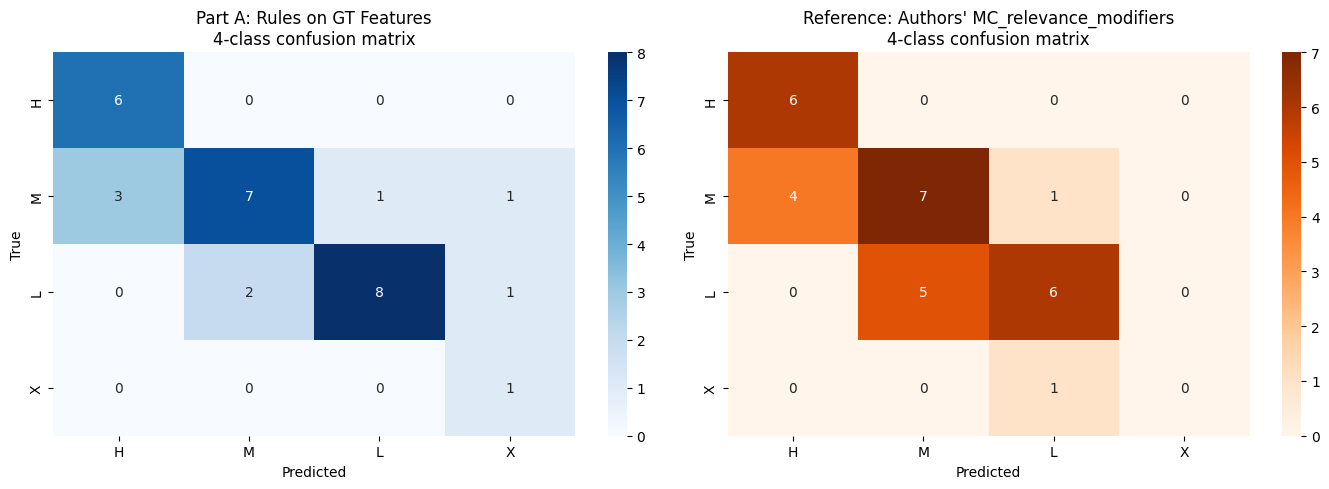

Saved confusion matrix to notebooks/results/


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4-class confusion matrix
cm_a = confusion_matrix(y_true, y_pred_a, labels=labels)
sns.heatmap(cm_a, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
            cmap="Blues", ax=axes[0])
axes[0].set_title("Part A: Rules on GT Features\n4-class confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# Compare to authors' MC_relevance_modifiers if available
if "MC_relevance_modifiers" in eval_df_a.columns:
    mc_mod = eval_df_a["MC_relevance_modifiers"].fillna("X").str.strip()
    cm_ref = confusion_matrix(y_true, mc_mod, labels=labels)
    sns.heatmap(cm_ref, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
                cmap="Oranges", ax=axes[1])
    axes[1].set_title("Reference: Authors' MC_relevance_modifiers\n4-class confusion matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
else:
    axes[1].text(0.5, 0.5, "MC_relevance_modifiers not available",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("Reference: Authors' MC_relevance_modifiers")

plt.tight_layout()
plt.savefig("notebooks/results/relevance_mechanistic_part_a_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved confusion matrix to notebooks/results/")

In [9]:
# Sanity check: compare our rule reconstruction to authors' MC_relevance_modifiers
if "MC_relevance_modifiers" in eval_df_a.columns:
    mc_mod = eval_df_a["MC_relevance_modifiers"].fillna("X").str.strip()
    mc_mod_valid = mc_mod[mc_mod.isin(labels)]
    gt_valid = y_true[mc_mod.isin(labels)]
    
    p_ref = precision_score(gt_valid.map(binary_collapse), mc_mod_valid.map(binary_collapse),
                             pos_label="relevant", zero_division=0)
    r_ref = recall_score(gt_valid.map(binary_collapse), mc_mod_valid.map(binary_collapse),
                          pos_label="relevant", zero_division=0)
    f1_ref = f1_score(gt_valid.map(binary_collapse), mc_mod_valid.map(binary_collapse),
                       pos_label="relevant", zero_division=0)
    macro_f1_ref = f1_score(gt_valid, mc_mod_valid, labels=labels, average="macro", zero_division=0)
    
    print("=== Reference: Authors' MC_relevance_modifiers ===")
    print(classification_report(gt_valid, mc_mod_valid, labels=labels, zero_division=0))
    print(f"Binary: P={p_ref:.3f}  R={r_ref:.3f}  F1={f1_ref:.3f}")
    print(f"4-class macro F1: {macro_f1_ref:.3f}")
else:
    print("MC_relevance_modifiers column not available; skipping reference comparison.")
    p_ref = r_ref = f1_ref = macro_f1_ref = None

=== Reference: Authors' MC_relevance_modifiers ===
              precision    recall  f1-score   support

           H       0.60      1.00      0.75         6
           M       0.58      0.58      0.58        12
           L       0.75      0.55      0.63        11
           X       0.00      0.00      0.00         1

    accuracy                           0.63        30
   macro avg       0.48      0.53      0.49        30
weighted avg       0.63      0.63      0.61        30

Binary: P=0.773  R=0.944  F1=0.850
4-class macro F1: 0.491


## Part B — End-to-End with LLM-Extracted Features

Run existing abstract extraction on dev subset, apply same rules, compare to GT.

In [26]:
from llm_metadata.extraction import run_manifest_extraction, ExtractionConfig
from llm_metadata.schemas.data_paper import DataPaperManifest, ExtractionMode
from llm_metadata.schemas.fuster_features import DatasetFeaturesExtraction

# Load the manifest using the proper contract
data_manifest = DataPaperManifest.load_csv("data/manifests/dev_subset_data_paper.csv")
print(f"Loaded manifest: {len(data_manifest.records)} records")

# Run extraction with DatasetFeaturesExtraction schema (same schema prompt_eval uses)
# Uses joblib cache — won't re-call API for records already cached with this schema
config = ExtractionConfig(text_format=DatasetFeaturesExtraction)
run_artifact = run_manifest_extraction(
    manifest=data_manifest,
    mode=ExtractionMode.ABSTRACT,
    config=config,
)

total = len(run_artifact.records)
success = sum(1 for r in run_artifact.records if r.status == "success")
errors = sum(1 for r in run_artifact.records if r.status == "error")
skipped = total - success - errors

print(f"\nExtraction complete:")
print(f"  Total records: {total}")
print(f"  Success: {success}")
print(f"  Skipped: {skipped}")
print(f"  Errors: {errors}")
print(f"  Total cost: ${run_artifact.total_cost_usd:.4f}")

2026-03-31 13:48:35 | INFO     | llm_metadata.extraction:run_manifest_extraction:354 | Starting manifest extraction mode=abstract records=30 parallelism=1 model=gpt-5-mini prompt_module=prompts.abstract skip_cache=False


2026-03-31 13:48:35 | INFO     | llm_metadata.extraction:run_manifest_extraction:386 | [1/30] Extracting gt_record_id=5 record_id=10.1093/jhered/esx103 title=Data from: Paternity analysis of wood turtles (Glyptemys insculpta) reveals complex mating patterns
2026-03-31 13:48:36 | INFO     | llm_metadata.gpt_extract:extract_from_text:139 | Starting text extraction model=gpt-5-mini schema=DatasetFeaturesExtraction chars=2194 cache=hit


Loaded manifest: 30 records


2026-03-31 13:48:36 | INFO     | llm_metadata.gpt_extract:extract_from_text:158 | Completed text extraction model=gpt-5-mini schema=DatasetFeaturesExtraction cache=hit cost=$0.0068 output_tokens=1725
2026-03-31 13:48:36 | INFO     | llm_metadata.extraction:run_manifest_extraction:403 | [1/30] Finished gt_record_id=5 status=success method=abstract_text cost=$0.0068
2026-03-31 13:48:36 | INFO     | llm_metadata.extraction:run_manifest_extraction:386 | [2/30] Extracting gt_record_id=9 record_id=10.1371/journal.pone.0128238 title=Data from: Resampling method for applying density-dependent habitat selection theory to wildlife surveys
2026-03-31 13:48:36 | INFO     | llm_metadata.gpt_extract:extract_from_text:139 | Starting text extraction model=gpt-5-mini schema=DatasetFeaturesExtraction chars=2862 cache=hit
2026-03-31 13:48:36 | INFO     | llm_metadata.gpt_extract:extract_from_text:158 | Completed text extraction model=gpt-5-mini schema=DatasetFeaturesExtraction cache=hit cost=$0.0052 outp


Extraction complete:
  Total records: 30
  Success: 30
  Skipped: 0
  Errors: 0
  Total cost: $0.2068


In [27]:
# Build DataFrame from run records (output is a dict, not a feature object)
records_data = []
for rec in run_artifact.records:
    row = {
        "record_id": rec.record_id,
        "gt_record_id": rec.gt_record_id,
        "status": rec.status,
    }
    if rec.output:
        feat = rec.output  # dict
        dt = feat.get("data_type")
        row["data_type"] = dt[0] if isinstance(dt, list) and dt else (dt if dt else None)
        row["temp_range_i"] = feat.get("temp_range_i")
        row["temp_range_f"] = feat.get("temp_range_f")
        row["spatial_range_km2"] = feat.get("spatial_range_km2")
        row["multispecies"] = feat.get("multispecies")
        row["threatened_species"] = feat.get("threatened_species")
        row["new_species_science"] = feat.get("new_species_science")
        row["new_species_region"] = feat.get("new_species_region")
        row["bias_north_south"] = feat.get("bias_north_south")
    records_data.append(row)

pred_df = pd.DataFrame(records_data)
print(f"Prediction DataFrame: {len(pred_df)} rows")
print(pred_df[["record_id", "gt_record_id", "status", "data_type", "temp_range_i", "temp_range_f", "spatial_range_km2"]].head())

Prediction DataFrame: 30 rows
                      record_id  gt_record_id   status         data_type  \
0         10.1093/jhered/esx103             5  success  genetic_analysis   
1  10.1371/journal.pone.0128238             9  success         abundance   
2  10.1371/journal.pone.0073695            11  success      distribution   
3             10.1002/ece3.4685            12  success              None   
4         10.1093/jhered/esw073            19  success  genetic_analysis   

   temp_range_i  temp_range_f  spatial_range_km2  
0        2006.0        2007.0                NaN  
1           NaN           NaN                NaN  
2        1999.0        2011.0                NaN  
3        2004.0        2011.0                NaN  
4        2011.0        2014.0                NaN  


In [28]:
# Join with GT on gt_record_id / id
pred_with_gt = pred_df.merge(
    eval_df[["id", "gt_relevance"]],
    left_on="gt_record_id",
    right_on="id",
    how="inner"
)
print(f"Records with GT match: {len(pred_with_gt)}")

# Apply rule-based scoring to LLM-extracted features
results_b = pred_with_gt.apply(classify_relevance, axis=1, result_type="expand")
pred_eval_df = pred_with_gt.join(results_b)

print("\nSample results:")
cols_b = ["record_id", "data_type", "temp_range_i", "temp_range_f", "spatial_range_km2",
          "pred_relevance", "gt_relevance"]
pred_eval_df[cols_b].head(8)

Records with GT match: 30

Sample results:


,record_id,data_type,temp_range_i,temp_range_f,spatial_range_km2,pred_relevance,gt_relevance
0,10.1093/jhered/esx103,genetic_analysis,2006.0,2007.0,NaN,M,M
1,10.1371/journal.pone.0128238,abundance,NaN,NaN,NaN,X,L
2,10.1371/journal.pone.0073695,distribution,1999.0,2011.0,NaN,M,M
3,10.1002/ece3.4685,None,2004.0,2011.0,NaN,X,M
4,10.1093/jhered/esw073,genetic_analysis,2011.0,2014.0,NaN,L,M
5,10.1002/ece3.3906,genetic_analysis,NaN,NaN,NaN,X,H
6,10.1111/ddi.12496,genetic_analysis,2010.0,2014.0,NaN,L,M
7,10.1002/ece3.1476,abundance,NaN,NaN,535355.0,H,H


In [29]:
y_true_b = pred_eval_df["gt_relevance"]
y_pred_b = pred_eval_df["pred_relevance"]

print("=== Part B: Rules on LLM-Extracted Features ===\n")
print(classification_report(y_true_b, y_pred_b, labels=labels, zero_division=0))

y_true_b_bin = y_true_b.map(binary_collapse)
y_pred_b_bin = y_pred_b.map(binary_collapse)

p_b = precision_score(y_true_b_bin, y_pred_b_bin, pos_label="relevant", zero_division=0)
r_b = recall_score(y_true_b_bin, y_pred_b_bin, pos_label="relevant", zero_division=0)
f1_b = f1_score(y_true_b_bin, y_pred_b_bin, pos_label="relevant", zero_division=0)
macro_f1_b = f1_score(y_true_b, y_pred_b, labels=labels, average="macro", zero_division=0)

print(f"\nBinary (H+M=relevant vs L+X=not_relevant):")
print(f"  Precision: {p_b:.3f}  Recall: {r_b:.3f}  F1: {f1_b:.3f}")
print(f"\n4-class macro F1: {macro_f1_b:.3f}")

=== Part B: Rules on LLM-Extracted Features ===

              precision    recall  f1-score   support

           H       1.00      0.17      0.29         6
           M       1.00      0.17      0.29        12
           L       0.33      0.27      0.30        11
           X       0.06      1.00      0.11         1

    accuracy                           0.23        30
   macro avg       0.60      0.40      0.24        30
weighted avg       0.72      0.23      0.28        30


Binary (H+M=relevant vs L+X=not_relevant):
  Precision: 1.000  Recall: 0.167  F1: 0.286

4-class macro F1: 0.244


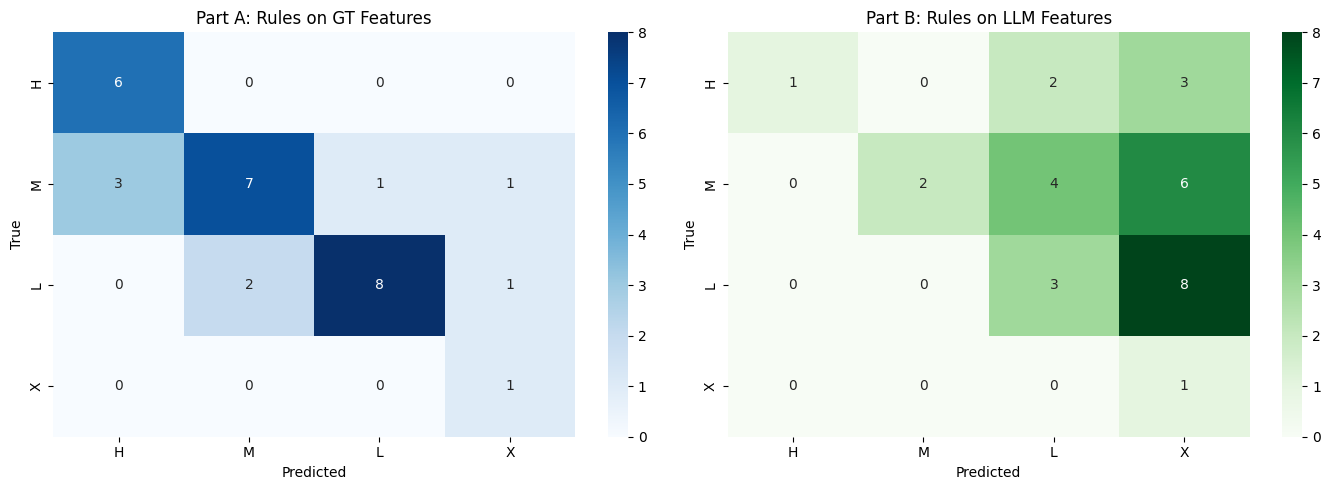

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_a2 = confusion_matrix(eval_df_a["gt_relevance"], eval_df_a["pred_relevance"], labels=labels)
sns.heatmap(cm_a2, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
            cmap="Blues", ax=axes[0])
axes[0].set_title("Part A: Rules on GT Features")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

cm_b = confusion_matrix(y_true_b, y_pred_b, labels=labels)
sns.heatmap(cm_b, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
            cmap="Greens", ax=axes[1])
axes[1].set_title("Part B: Rules on LLM Features")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("notebooks/results/relevance_mechanistic_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary Comparison Table

In [31]:
# Build comparison table
rows = [
    {
        "Method": "R1-A: Rules on GT features",
        "4-class macro F1": round(macro_f1_a, 3),
        "Binary F1 (relevant)": round(f1_a, 3),
        "Binary P": round(p_a, 3),
        "Binary R": round(r_a, 3),
    },
    {
        "Method": "R1-B: Rules on LLM features",
        "4-class macro F1": round(macro_f1_b, 3),
        "Binary F1 (relevant)": round(f1_b, 3),
        "Binary P": round(p_b, 3),
        "Binary R": round(r_b, 3),
    },
]

if p_ref is not None:
    rows.append({
        "Method": "Authors' MC_relevance_modifiers (reference)",
        "4-class macro F1": round(macro_f1_ref, 3),
        "Binary F1 (relevant)": round(f1_ref, 3),
        "Binary P": round(p_ref, 3),
        "Binary R": round(r_ref, 3),
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv("notebooks/results/relevance_mechanistic_summary.csv", index=False)
print("Saved summary to notebooks/results/relevance_mechanistic_summary.csv\n")
summary_df

Saved summary to notebooks/results/relevance_mechanistic_summary.csv



,Method,4-class macro F1,Binary F1 (relevant),Binary P,Binary R
0,R1-A: Rules on GT features,0.692,0.889,0.889,0.889
1,R1-B: Rules on LLM features,0.244,0.286,1.000,0.167
2,Authors' MC_relevance_modifiers (reference),0.491,0.850,0.773,0.944


## Delta Analysis — Part A vs Part B

How much does imperfect feature extraction degrade relevance scoring?

In [32]:
# Compare Part A and Part B predictions side-by-side
# Align on shared gt_record_id
shared_ids = set(eval_df_a["id"]) & set(pred_eval_df["id"])
part_a_sub = eval_df_a[eval_df_a["id"].isin(shared_ids)][
    ["id", "data_type", "temp_range_i", "temp_range_f", "spatial_range_km2", "pred_relevance", "gt_relevance"]
].rename(columns={
    "data_type": "gt_data_type", "temp_range_i": "gt_temp_i", "temp_range_f": "gt_temp_f",
    "spatial_range_km2": "gt_spatial", "pred_relevance": "pred_a"
})

part_b_sub = pred_eval_df[pred_eval_df["id"].isin(shared_ids)][
    ["id", "data_type", "temp_range_i", "temp_range_f", "spatial_range_km2", "pred_relevance"]
].rename(columns={
    "data_type": "llm_data_type", "temp_range_i": "llm_temp_i", "temp_range_f": "llm_temp_f",
    "spatial_range_km2": "llm_spatial", "pred_relevance": "pred_b"
})

delta_df = part_a_sub.merge(part_b_sub, on="id")
delta_df["match"] = delta_df["pred_a"] == delta_df["pred_b"]
delta_df["both_correct_a"] = delta_df["pred_a"] == delta_df["gt_relevance"]
delta_df["both_correct_b"] = delta_df["pred_b"] == delta_df["gt_relevance"]

print(f"Records with both Part A and Part B predictions: {len(delta_df)}")
print(f"Part A == Part B: {delta_df['match'].sum()}/{len(delta_df)} ({delta_df['match'].mean():.1%})")
print(f"Correct in A: {delta_df['both_correct_a'].sum()}")
print(f"Correct in B: {delta_df['both_correct_b'].sum()}")
print(f"\nDegraded by LLM features (A correct, B wrong): {(delta_df['both_correct_a'] & ~delta_df['both_correct_b']).sum()}")
print(f"Improved by LLM features (A wrong, B correct): {(~delta_df['both_correct_a'] & delta_df['both_correct_b']).sum()}")

delta_df[["id", "gt_relevance", "gt_data_type", "llm_data_type", "pred_a", "pred_b", "match"]].head(10)

Records with both Part A and Part B predictions: 30
Part A == Part B: 10/30 (33.3%)
Correct in A: 22
Correct in B: 7

Degraded by LLM features (A correct, B wrong): 15
Improved by LLM features (A wrong, B correct): 0


,id,gt_relevance,gt_data_type,llm_data_type,pred_a,pred_b,match
0,5,M,EBV genetic analysis,genetic_analysis,M,M,True
1,9,L,density,abundance,L,X,False
2,11,M,presence only,distribution,M,M,True
3,12,M,other,None,H,X,False
4,19,M,"presence only, EBV genetic analysis",genetic_analysis,M,L,False
5,24,H,EBV genetic analysis,genetic_analysis,H,X,False
6,27,M,"presence only, EBV genetic analysis",genetic_analysis,M,L,False
7,29,H,abundance,abundance,H,H,True
8,30,H,presence only,traits,H,L,False
9,31,L,EBV genetic analysis,genetic_analysis,L,L,True
